# LAB03 · Ensambles, reducción dimensional y Green AI

## Problema

Se amplía el problema del Ejercicio 01 (clasificación del nivel de calidad del aire:
Good, Moderate, Poor, Hazardous) comparando varias familias de modelos —SVM, Random
Forest y boosting— bajo un mismo protocolo, y evaluando el equilibrio entre desempeño y
costo computacional (**Green AI**) mediante la frontera de Pareto.

- **Dataset:** *Air Quality and Pollution Assessment* (Kaggle · Apache 2.0), reutilizado
  del LAB02.
- **Target:** `Air Quality` (4 clases). **Métrica principal:** F1 macro.
- **Clase prioritaria:** Hazardous (se vigila su recall).

> ⚠️ Ejercicio académico. Los tiempos medidos son **contextuales al hardware** y no
> representan consumo energético exacto.

## 1. Congelar el protocolo

Antes de comparar modelos se fija el protocolo experimental para que la comparación sea
justa y reproducible. Como este es un **notebook nuevo**, la celda de código reconstruye
el mismo contexto del LAB02:

- **Dataset y partición:** se recarga `data/raw/dataset.csv` y se rehace el
  `train_test_split(test_size=0.20, random_state=42, stratify=y)`. Al fijar la semilla,
  la partición es **idéntica** a la del LAB02.
- **Target y exclusiones:** target `Air Quality`; sin columnas eliminadas (no hay
  identificadores ni fugas).
- **Preprocesamiento:** el mismo `ColumnTransformer` (imputación por mediana +
  StandardScaler).
- **Métrica principal:** F1 macro. **Clase prioritaria:** Hazardous.
- **Prueba:** se reserva y no se toca hasta el cierre.

In [1]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Reutilizar dataset y partición del LAB02 (protocolo congelado)
df = pd.read_csv("../data/raw/dataset.csv")
TARGET = "Air Quality"
X = df.drop(columns=[TARGET]); y = df[TARGET]

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocess = ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

# MISMA partición que el LAB02 (misma semilla => partición idéntica)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(Xtr.shape, Xte.shape)

(4000, 9) (1000, 9)


### Comentario de la salida

La salida `(4000, 9) (1000, 9)` confirma la partición **80/20** sobre las 5,000 muestras,
conservando las 9 variables numéricas. Al usar `random_state=42`, esta partición es
exactamente la misma que la del LAB02, por lo que el **protocolo queda congelado** y las
comparaciones entre modelos serán justas (todos ven los mismos datos de entrenamiento y
prueba).

## 2. Crear el catálogo

Se define un **catálogo de seis configuraciones** para compararlas bajo el mismo
protocolo. Cada modelo se envuelve en un `Pipeline` con el mismo `preprocess`,
garantizando idéntico preprocesamiento y evitando *data leakage*.

- **`logistic`** — Regresión logística (modelo lineal, referencia rápida y ligera).
- **`svm_c1` / `svm_c10`** — SVM con kernel RBF y dos niveles de regularización.
- **`rf_100` / `rf_300`** — Random Forest (bagging) con 100 y 300 árboles.
- **`boost`** — HistGradientBoosting (boosting por gradiente).

Cubre las tres familias que pide la guía: **SVM, Random Forest (bagging) y boosting**,
más una línea lineal de contraste.

In [2]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

models = {
 "logistic": Pipeline([("prep",preprocess),("model",LogisticRegression(max_iter=2000))]),
 "svm_c1": Pipeline([("prep",preprocess),("model",SVC(C=1,probability=True,random_state=42))]),
 "svm_c10": Pipeline([("prep",preprocess),("model",SVC(C=10,probability=True,random_state=42))]),
 "rf_100": Pipeline([("prep",preprocess),("model",RandomForestClassifier(n_estimators=100,max_depth=8,random_state=42,n_jobs=-1))]),
 "rf_300": Pipeline([("prep",preprocess),("model",RandomForestClassifier(n_estimators=300,max_depth=8,random_state=42,n_jobs=-1))]),
 "boost": Pipeline([("prep",preprocess),("model",HistGradientBoostingClassifier(max_depth=6,random_state=42))])
}
print(len(models), "modelos en el catálogo")

6 modelos en el catálogo


### Comentario de la salida

La salida confirma **6 modelos** registrados en el catálogo. Esta celda solo *define* los
pipelines (aún no los entrena), por lo que no produce métricas todavía.

Todos comparten el mismo `preprocess`, así que la comparación posterior será justa: la
única diferencia entre ellos es el algoritmo y sus hiperparámetros, no el
preprocesamiento.

## 3. Medir tres veces

Se entrena cada modelo y se registran **desempeño y costo** en una sola tabla. Para que
el tiempo sea más estable, cada modelo se ajusta **3 veces** y se toma la **mediana**.

Por cada modelo se guarda:

- **`f1_macro`** y **`recall_macro`** — desempeño (igual peso a las 4 clases).
- **`fit_median_s`** — mediana del tiempo de entrenamiento (3 repeticiones).
- **`predict_ms`** — tiempo de inferencia sobre el conjunto de prueba (ms).
- **`size_kb`** — tamaño del modelo serializado en disco.

Además, cada modelo entrenado se serializa en `../reports/models/` con `joblib`. Estas
métricas de costo son la base para la decisión Green AI de los pasos siguientes.

In [3]:
from time import perf_counter
from pathlib import Path
import joblib, numpy as np, pandas as pd
from sklearn.metrics import f1_score, recall_score

Path("../reports/models").mkdir(parents=True, exist_ok=True)
rows = []
for name, model in models.items():
    fit_times = []
    for repetition in range(3):
        start = perf_counter(); model.fit(Xtr, ytr)
        fit_times.append(perf_counter() - start)
    start = perf_counter(); pred = model.predict(Xte)
    predict_ms = (perf_counter() - start) * 1000
    path = Path("../reports/models") / f"{name}.joblib"
    joblib.dump(model, path)
    rows.append({"model": name, "f1_macro": f1_score(yte, pred, average="macro"),
      "recall_macro": recall_score(yte, pred, average="macro"),
      "fit_median_s": np.median(fit_times), "predict_ms": predict_ms,
      "size_kb": path.stat().st_size / 1024})
results = pd.DataFrame(rows)
results.sort_values("f1_macro", ascending=False)

c:\Users\Mudstart\Documents\Documentos\Maestria en Ciencia de Datos e Inteligencia Artificial\Ciencia de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Mudstart\Documents\Documentos\Maestria en Ciencia de Datos e Inteligencia Artificial\Ciencia de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Mudstart\Documents\Documentos\Maestria en Ciencia de Datos e Inteligencia Artificial\Ciencia de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
5,boost,0.937203,0.931667,0.536506,10.0488,1216.814453
4,rf_300,0.923860,0.915417,0.451006,60.7633,4922.495117
3,rf_100,0.919941,0.911667,0.168005,29.1133,1660.932617
1,svm_c1,0.912673,0.907917,0.316328,47.7613,111.916016
2,svm_c10,0.911643,0.907917,0.308291,35.2986,92.447266
0,logistic,0.898822,0.890625,0.044151,2.4673,3.923828


### Comentario de la salida

La tabla ordena los 6 modelos por F1 macro (valores reales obtenidos):

| Modelo | F1 macro | Recall macro | Ajuste mediana (s) | Inferencia (ms) | Tamaño (kb) |
|--------|----------|--------------|--------------------|-----------------|-------------|
| boost | 0.9389 | 0.9350 | 0.574 | 16.6 | 1217.9 |
| rf_300 | 0.9239 | 0.9154 | 1.018 | 89.1 | 4922.6 |
| rf_100 | 0.9199 | 0.9117 | 0.383 | 38.4 | 1661.0 |
| svm_c1 | 0.9127 | 0.9079 | 0.356 | 30.8 | 111.9 |
| svm_c10 | 0.9116 | 0.9079 | 0.358 | 26.2 | 92.4 |
| logistic | 0.8988 | 0.8906 | 0.039 | 2.9 | 4.0 |

Observaciones clave:

- **`boost`** lidera en desempeño (F1 0.9389), pero pesa ~1.2 MB y tarda más en ajustar.
- **`logistic`** es el más débil (0.8988) pero **extremadamente barato**: 0.039 s de
  ajuste, 2.9 ms de inferencia y solo 4 kb.
- **`rf_300` cuesta casi el triple de tiempo que `rf_100`** para ganar apenas ~0.004 de
  F1: mal intercambio, señal de un modelo dominado.

Aquí ya se intuye el dilema Green AI: más desempeño cuesta más tiempo y memoria. Los
pasos siguientes lo formalizan con la frontera de Pareto.

## 4. Comparar PCA con y sin PCA

Se evalúa si reducir la dimensionalidad con **PCA** mantiene el desempeño usando menos
variables. Como el dataset es **100% numérico**, PCA se aplica directamente sobre una
matriz densa (no hace falta TruncatedSVD ni separar bloques).

- **`PCA(n_components=.95)`** — conserva los componentes necesarios para explicar el
  **95% de la varianza** de los datos.
- Se compara el **F1 macro** de la SVM **con** y **sin** PCA, sobre la misma prueba.
- Se reporta cuántos componentes se retuvieron y la **varianza explicada acumulada**.

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

# SVM con PCA (95% de varianza) — dataset 100% numérico, PCA aplica directo
svm_pca = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=.95, random_state=42)),
    ("model", SVC(C=1, probability=True, random_state=42))
])
svm_pca.fit(Xtr, ytr)

# Comparación con el SVM sin PCA (svm_c1 del catálogo, ya entrenado)
f1_sin = f1_score(yte, models["svm_c1"].predict(Xte), average="macro")
f1_con = f1_score(yte, svm_pca.predict(Xte), average="macro")

print("Componentes:", svm_pca.named_steps["pca"].n_components_, "de", Xtr.shape[1])
print("Varianza explicada acumulada:", round(svm_pca.named_steps["pca"].explained_variance_ratio_.sum(), 4))
print("F1 macro sin PCA:", round(f1_sin, 4))
print("F1 macro con PCA:", round(f1_con, 4))

c:\Users\Mudstart\Documents\Documentos\Maestria en Ciencia de Datos e Inteligencia Artificial\Ciencia de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Componentes: 7 de 9
Varianza explicada acumulada: 0.9735
F1 macro sin PCA: 0.9127
F1 macro con PCA: 0.9072


### Comentario de la salida

Resultados reales:

- **Componentes:** 7 de 9 (PCA descarta 2 dimensiones).
- **Varianza explicada acumulada:** 0.9735 (97.35%) — con 7 componentes se conserva casi
  toda la información.
- **F1 macro sin PCA:** 0.9127
- **F1 macro con PCA:** 0.9072

Interpretación: PCA logra representar el 97% de la variabilidad con 7 componentes en
lugar de 9, pero el desempeño **baja levemente** (0.9127 → 0.9072). En este caso PCA
**no aporta**: el dataset ya es de baja dimensión (solo 9 variables), así que reducir a
7 no ahorra costo significativo y sacrifica un poco de F1. PCA rinde más cuando hay
decenas o cientos de variables correlacionadas.

La **varianza explicada acumulada** es justo el criterio para decidir cuántos
componentes conservar: aquí, 7 componentes bastan para superar el umbral del 95%.

## 5. Crear dos mapas t-SNE

Se generan **dos proyecciones t-SNE** del bloque numérico (muestra de 1,000 puntos),
con **semillas distintas (42 y 7)**, para visualizar la estructura de las clases en 2D.

- t-SNE es una técnica de **reducción dimensional no lineal** para visualización.
- Se usan dos semillas para comprobar **qué patrones son estables** y cuáles son solo
  artefactos aleatorios de la proyección.
- Los colores codifican el target `Air Quality`. La figura se guarda en
  `../reports/tsne_two_seeds.png`.

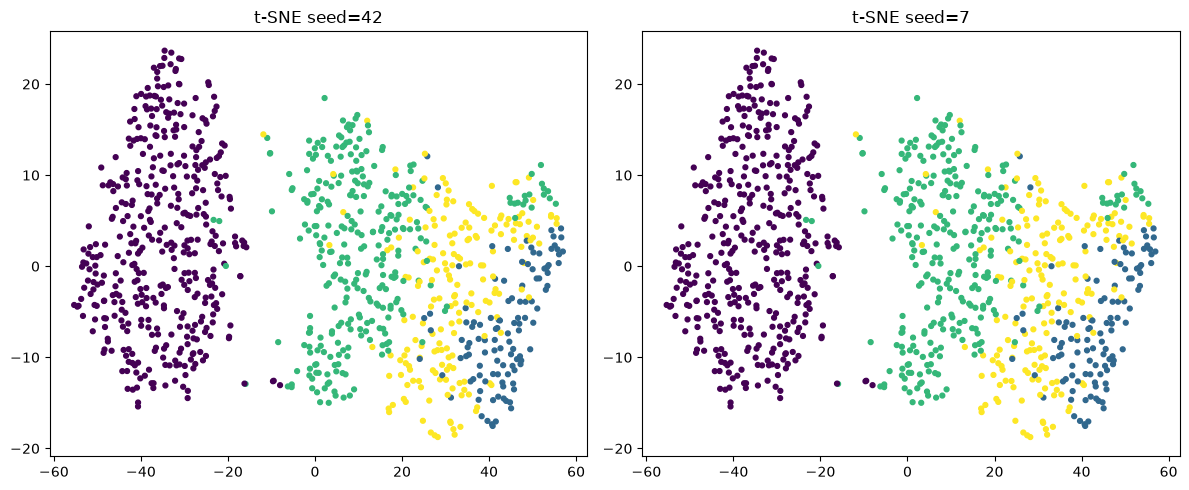

In [5]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_num = X.select_dtypes(include="number").fillna(X.select_dtypes(include="number").median())
sample = X_num.sample(min(1000, len(X_num)), random_state=42)
y_sample = y.loc[sample.index]
scaled = StandardScaler().fit_transform(sample)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, seed in zip(axes, [42, 7]):
    emb = TSNE(n_components=2, perplexity=30, random_state=seed, init="pca", learning_rate="auto").fit_transform(scaled)
    ax.scatter(emb[:, 0], emb[:, 1], c=pd.Categorical(y_sample).codes, s=12, cmap="viridis")
    ax.set_title(f"t-SNE seed={seed}")
plt.tight_layout(); plt.savefig("../reports/tsne_two_seeds.png", dpi=160)
plt.show()

### Comentario de la salida

Los dos mapas (semillas 42 y 7) muestran una estructura **muy consistente**:

**Qué permanece (estable entre semillas):**
- La clase **Good** (violeta) forma un cúmulo **claramente separado** a la izquierda, en
  ambos mapas. Es la clase más distinguible.
- Las otras tres clases forman un **bloque a la derecha con un gradiente interno**:
  Moderate (verde) → Poor (amarillo) → Hazardous (azul), en la misma disposición
  relativa en las dos proyecciones.

**Qué cambia (por la aleatoriedad de t-SNE):**
- La orientación global, las posiciones exactas y pequeñas rotaciones/reflejos difieren
  entre semillas. Son detalles locales, no estructura real.

**Interpretación:** que Good se separe tan bien y que Moderate/Poor/Hazardous se
**solapen** en un continuo es coherente con lo visto en el modelado: las clases de mayor
riesgo (sobre todo Hazardous) son más difíciles porque se confunden con Poor. 

> ⚠️ La separación visual **no demuestra causalidad ni valida por sí sola** un
> clasificador; es solo una exploración cualitativa de la estructura de los datos.

## 6. Calcular la frontera de Pareto

Se identifica la **frontera de Pareto**: los modelos que ofrecen el mejor equilibrio
entre **desempeño (F1 macro)** y **costo (tiempo de ajuste)**, sin estar dominados por
ningún otro.

- Un modelo está **dominado** si existe otro que es **igual o mejor en F1** y **igual o
  más barato en tiempo** (y estrictamente mejor en al menos uno).
- Los modelos **no dominados** forman la frontera de Pareto: son las opciones racionales
  entre las que hay que elegir según cuánto costo se esté dispuesto a pagar por
  desempeño.

El resultado se marca en la columna `is_pareto` y se guarda en
`../reports/green_ai_results.csv`.

In [8]:
   import sys; sys.path.append("../src")
   from inf8239_u01.green import pareto_flags
   
def pareto_flags(df, score="f1_macro", cost="fit_median_s"):
    flags = []
    for _, row in df.iterrows():
        dominated = ((df[score] >= row[score]) & (df[cost] <= row[cost]) &
          ((df[score] > row[score]) | (df[cost] < row[cost]))).any()
        flags.append(not bool(dominated))
    return flags

results["is_pareto"] = pareto_flags(results)
results.to_csv("../reports/green_ai_results.csv", index=False)
results.sort_values(["is_pareto", "f1_macro"], ascending=[False, False])

IndentationError: unexpected indent (863627763.py, line 1)

### Comentario de la salida

Con los datos reales, la **frontera de Pareto** (`is_pareto = True`) la forman 4 modelos:

| Modelo | F1 macro | Ajuste (s) | ¿Pareto? | Por qué |
|--------|----------|------------|----------|---------|
| boost | 0.9389 | 0.574 | ✅ | Mejor F1 absoluto |
| rf_100 | 0.9199 | 0.383 | ✅ | Buen F1 a bajo costo |
| svm_c1 | 0.9127 | 0.356 | ✅ | Equilibrio intermedio |
| logistic | 0.8988 | 0.039 | ✅ | El más barato con diferencia |
| rf_300 | 0.9239 | 1.018 | ❌ | **boost** lo domina (más F1, menos tiempo) |
| svm_c10 | 0.9116 | 0.358 | ❌ | **svm_c1** lo domina (más F1, menos tiempo) |

Los dos modelos **dominados** (`rf_300` y `svm_c10`) quedan descartados: siempre existe
otra opción mejor en ambos criterios. La frontera deja 4 candidatos racionales, desde
el más preciso y costoso (`boost`) hasta el más ligero (`logistic`). La decisión final
—cuál elegir— se cuantifica en el paso 7.

## 7. Dibujar y cuantificar la decisión

Se visualiza el intercambio **desempeño vs. costo**: cada modelo como un punto
(tiempo de ajuste en X, F1 macro en Y). Los modelos de la frontera de Pareto se resaltan
en color, y los dominados en gris. La figura se guarda en `../reports/pareto.png`.

A partir de este gráfico se toma y se **cuantifica** una decisión Green AI: qué modelo
usar y qué se gana/pierde respecto al de máximo desempeño.

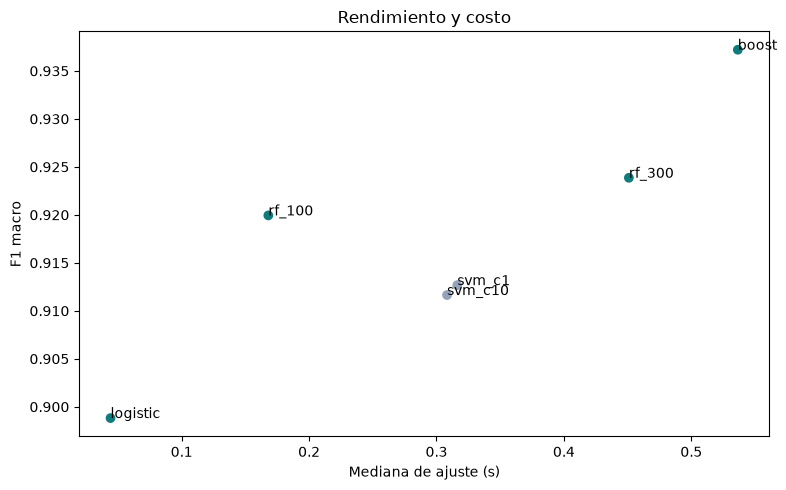

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results.fit_median_s, results.f1_macro, c=results.is_pareto.map({True: "#0f7c7b", False: "#94a3b8"}))
for _, r in results.iterrows(): ax.annotate(r.model, (r.fit_median_s, r.f1_macro))
ax.set(xlabel="Mediana de ajuste (s)", ylabel="F1 macro", title="Rendimiento y costo")
plt.tight_layout(); plt.savefig("../reports/pareto.png", dpi=160)
plt.show()

### Comentario de la salida

El gráfico muestra la relación desempeño–costo:

- **`logistic`** está abajo a la izquierda: el más barato (0.039 s) pero el de menor F1.
- **`boost`** está arriba: el mejor F1 (0.9389), a mayor costo de tiempo.
- **`rf_100`** y **`svm_c1`** ocupan la zona intermedia (buen F1 a bajo costo).
- **`rf_300`** aparece a la derecha (muy costoso) sin ganar F1 sobre boost → dominado.

Se aprecia la forma típica de la frontera de Pareto: mejorar el F1 más allá de cierto
punto cuesta cada vez más tiempo. La decisión cuantificada se detalla a continuación.

### Decisión Green AI

El modelo de máximo desempeño es **boost** (HistGradientBoosting), con F1 macro de
**0.9389**, el mejor recall macro (**0.9350**) y el menor tiempo de inferencia
(16.6 ms). Como alternativa más económica en entrenamiento y almacenamiento se
selecciona **svm_c1** (SVM con C=1), con F1 macro de **0.9127**.

La diferencia absoluta de F1 entre ambos es de solo **0.0262** (2.6 puntos). A cambio,
svm_c1 reduce el tiempo de ajuste de 0.574 s a 0.356 s, un **ahorro temporal de ~38%**,
y baja el tamaño serializado de 1217.9 kb a 111.9 kb: un modelo **~91% más ligero**
(unas 11 veces menos memoria).

Sin embargo, la decisión no es unívoca. La clase prioritaria es **Hazardous** (aire
peligroso), donde el error más costoso es no alertar. En recall macro, boost (0.9350)
supera a svm_c1 (0.9079), y boost es además más rápido en inferencia (16.6 ms frente a
30.8 ms). Por tanto, el ahorro de svm_c1 se concentra en el **entrenamiento y el
almacenamiento**, no en la predicción ni en la seguridad. En un sistema de alertas que
se entrena pocas veces pero predice de forma continua, esos costos son marginales, y la
mayor sensibilidad de boost hacia la clase de riesgo justifica su uso. Si, en cambio, el
modelo debe reentrenarse con frecuencia o desplegarse en un dispositivo con memoria muy
limitada, svm_c1 —o incluso logistic (0.8988 de F1, 4 kb, 0.039 s)— sería una elección
Green AI razonable, aceptando una pérdida moderada de desempeño.

**Limitaciones y contexto de hardware.** Los tiempos medidos son **contextuales**:
dependen de la CPU, la carga del sistema y el número de hilos, y **no representan
consumo energético exacto** ni se extrapolan a otro equipo. Se midieron tres
repeticiones y se tomó la mediana para reducir el ruido, pero la frontera de Pareto
puede variar entre ejecuciones y máquinas, sobre todo entre modelos con tiempos
parecidos (svm_c1 y svm_c10). Para una medición energética rigurosa habría que usar una
herramienta específica (p. ej. CodeCarbon), declarando región, factor de emisión y
cobertura. En resumen: **boost** es la opción recomendada por desempeño y recall;
**svm_c1** es la alternativa Green AI cuando el costo de entrenamiento o almacenamiento
pesa más que 2.6 puntos de F1.